# Linear Regression — Intuition

**Goal.** Build a mental picture of linear regression *before* tou$\chi$ng any math.
Four questions, answered with pictures only:

1. What does the data look like?
2. Many lines could fit — which one is "best"?
3. How does the error behave as we move the line?
4. When does a straight line stop being a good idea?

No for$\mu$las here. The math lives in `02_mathematics.ipynb`.

> **Note.** Section 2 has a slider you can drag in a live Jupyter kernel.
> If you are reading this on GitHub, the slider will be frozen — scroll down
> to the three-panel static snapshot that follows it for the same idea.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Checkbox

rng = np.random.default_rng(42)

# Toy dataset: house size (m^2) vs price (k$)
true_slope, true_intercept = 3.5, 20.0
x = rng.uniform(30, 150, size=40)
noise = rng.normal(0, 25, size=x.size)
y = true_slope * x + true_intercept + noise

xs = np.linspace(x.min(), x.max(), 100)
plt.rcParams["figure.dpi"] = 90


## 1. The data

We have 40 houses. For each, we know its **size** (m^2) and its **price** (k$).
Question: given a new house's size, can we guess its price?


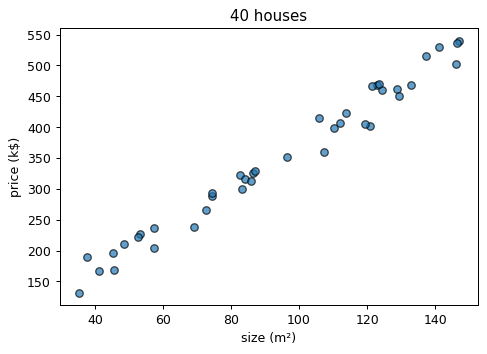

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, alpha=0.7, edgecolor="k")
ax.set_xlabel("size (m²)")
ax.set_ylabel("price (k$)")
ax.set_title("40 houses")
plt.show()


## 2. Drag the line — and feel the residuals shrink

A line is defined by **slope** (how steep) and **intercept** (where it crosses zero).
For each house, the **residual** is the gap between predicted and actual price.
A good line makes those gaps small *on average*.

**Drag the sliders below.** Try to make MSE (in the title) as small as you can.
The true slope is somewhere between 3 and 4.


In [3]:
def show_fit(slope=2.0, intercept=50.0, show_residuals=True):
    plt.close("all")  # prevent figure stacking when slider is dragged
    y_hat = slope * x + intercept
    mse = np.mean((y - y_hat) ** 2)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(x, y, alpha=0.6, edgecolor="k", zorder=3)
    ax.plot(xs, slope * xs + intercept, color="crimson", lw=2, zorder=2)
    if show_residuals:
        ax.vlines(x, np.minimum(y, y_hat), np.maximum(y, y_hat),
                  color="red", alpha=0.4, zorder=1)
    ax.set_xlabel("size (m²)")
    ax.set_ylabel("price (k$)")
    ax.set_title(f"slope = {slope:.2f},  intercept = {intercept:.1f}  →  MSE = {mse:.0f}")
    ax.set_ylim(-50, 750)
    plt.show()

interact(
    show_fit,
    slope=FloatSlider(min=0, max=7, step=0.1, value=2.0),
    intercept=FloatSlider(min=-60, max=100, step=2, value=50),
    show_residuals=Checkbox(value=True, description="show residuals"),
);


interactive(children=(FloatSlider(value=2.0, description='slope', max=7.0), FloatSlider(value=50.0, descriptio…

### Static snapshot — three positions of the slider

For readers without a live kernel, here are three representative slider settings
side by side. Red segments are residuals; the number in each title is the MSE.
The middle panel is roughly what you converge to by dragging.


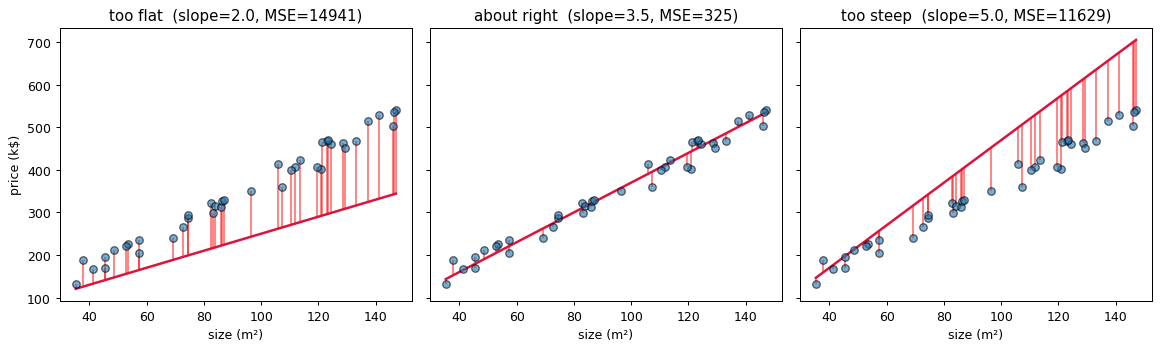

In [4]:
candidates = [(2.0, 50, "too flat"), (3.5, 20, "about right"), (5.0, -30, "too steep")]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (m, b, label) in zip(axes, candidates):
    y_hat = m * x + b
    mse = np.mean((y - y_hat) ** 2)
    ax.scatter(x, y, alpha=0.6, edgecolor="k", zorder=3)
    ax.plot(xs, m * xs + b, color="crimson", lw=2, zorder=2)
    ax.vlines(x, np.minimum(y, y_hat), np.maximum(y, y_hat),
              color="red", alpha=0.5, zorder=1)
    ax.set_title(f"{label}  (slope={m}, MSE={mse:.0f})")
    ax.set_xlabel("size (m²)")
axes[0].set_ylabel("price (k$)")
plt.tight_layout()
plt.show()


## 3. The loss landscape

Fix the intercept at 20 and sweep the slope. The error traces a smooth **bowl**
with exactly one bottom. The slope at that bottom is the "best" line.

This bowl shape is what makes automatic optimisation possible — and is why we
spend a whole notebook on it next (`03_optimization.ipynb`).


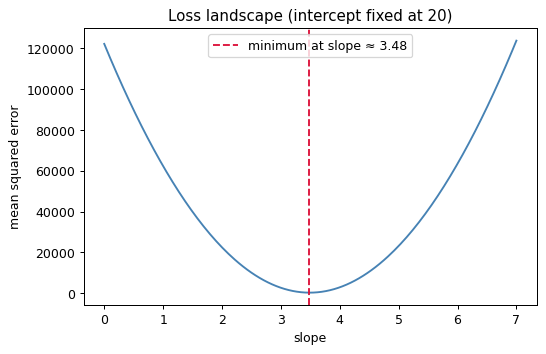

In [5]:
slopes = np.linspace(0, 7, 200)
errors = [np.mean((y - (m * x + 20)) ** 2) for m in slopes]
best = slopes[np.argmin(errors)]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(slopes, errors, color="steelblue")
ax.axvline(best, color="crimson", ls="--", label=f"minimum at slope ≈ {best:.2f}")
ax.set_xlabel("slope")
ax.set_ylabel("mean squared error")
ax.set_title("Loss landscape (intercept fixed at 20)")
ax.legend()
plt.show()


## 4. When the straight line stops working

Two situations break the picture above:

- **Outliers** — one bad point can drag the whole line.
- **Non-linear truth** — a straight line just cannot follow a curve.


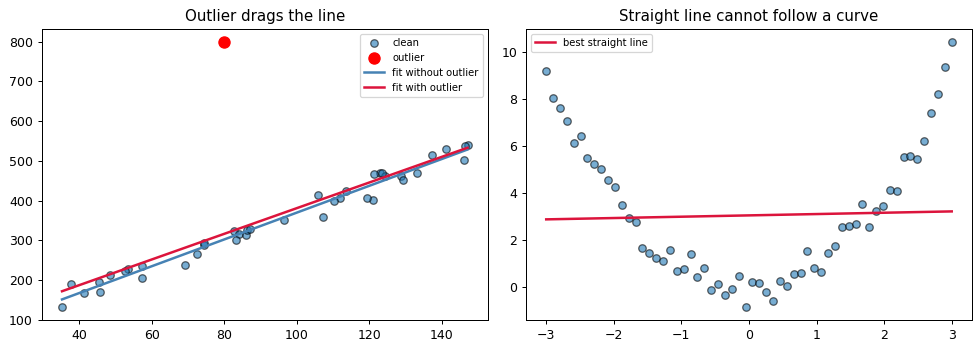

In [6]:
# (a) outlier
x_out = np.append(x, [80])
y_out = np.append(y, [800])  # one wildly wrong reading

# (b) non-linear truth
x_nl = np.linspace(-3, 3, 60)
y_nl = x_nl ** 2 + rng.normal(0, 0.5, size=x_nl.size)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

m1, b1 = np.polyfit(x, y, 1)
m2, b2 = np.polyfit(x_out, y_out, 1)
axes[0].scatter(x, y, alpha=0.6, edgecolor="k", label="clean")
axes[0].scatter([80], [800], color="red", s=80, label="outlier", zorder=3)
axes[0].plot(xs, m1 * xs + b1, color="steelblue", lw=2, label="fit without outlier")
axes[0].plot(xs, m2 * xs + b2, color="crimson", lw=2, label="fit with outlier")
axes[0].set_title("Outlier drags the line")
axes[0].legend(fontsize=8)

m3, b3 = np.polyfit(x_nl, y_nl, 1)
axes[1].scatter(x_nl, y_nl, alpha=0.6, edgecolor="k")
axes[1].plot(x_nl, m3 * x_nl + b3, color="crimson", lw=2, label="best straight line")
axes[1].set_title("Straight line cannot follow a curve")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Takeaway

- Linear regression draws **one** straight line through a cloud of points.
- "Best" = smallest sum of squared residuals.
- The error is a bowl-shaped function of the slope, so finding the bottom is easy.
- It breaks when the truth is curved or when a few points are far off.

Next: `02_mathematics.ipynb` puts numbers on every word above.
